In [37]:
import MDAnalysis as mda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from pathlib import Path
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture as BGMM

from statsmodels.stats.diagnostic import lilliefors

In [2]:
%load_ext autoreload
%autoreload 1

%aimport sb_bond_functions
%aimport shap_functions

import sb_bond_functions as ba
import shap_functions

In [3]:
DATA = Path("/wrk/romiromi/work/bond_analysis/bondflow_data/AMPAR_data")

reference_struc = DATA /'AMPAR.pdb'
trajectory = [DATA / 'every10_AMPAR.xtc']


In [4]:
all_pairs, current_pairs, categorized_contacts, combined_coords, n_mainchain_residues, pvalue_df = ba.compute_com_contacts(trajectory, reference_struc, 
                        batch_size=100, stride=1, 
                        mc_contact_threshold=8.0, sc_contact_threshold=8.0, 
                        mc_sc_contact_threshold=8.0, variance_percentile=75, pvalue_threshold=0.05,
                        n_jobs=1)

every10_AMPAR.xtc: 100%|██████████| 8016/8016 [00:32<00:00, 246.77it/s]


Mainchain-Mainchain pairs: 1485226
Sidechain-Sidechain pairs: 1485226
Mainchain-Sidechain pairs: 2972176


Stage 1: Contact Filter: 100%|██████████| 14853/14853 [11:38<00:00, 21.25it/s]


MC-MC pairs after contact filter: 20,441


Stage 1: Contact Filter: 100%|██████████| 14853/14853 [11:24<00:00, 21.71it/s]


...

MC-SC pairs after contact filter: 11,655
Total pairs after Stage 1 (all classes): 35,844


Stage 2: Calculating Variances: 100%|██████████| 359/359 [00:19<00:00, 18.17it/s]


Pairs after variance filter: 8,961


Stage 3: Calculating Distributions: 100%|██████████| 90/90 [00:08<00:00, 11.00it/s]

Pairs after distribution filter: 8,953


## Search for salt bridges ##

In [5]:
# Search for salt bridges in the current pairs
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map_filtered(reference_struc, trajectory, current_pairs, distance_threshold=5.0)
print(binary_contact_map.shape)

print(distance_map.shape)

(61, 8016)
(61, 8016)


In [6]:
# Create sorted distance dataframe to look at salt bridge distances 
# and their variance across the trajectory/trajectories
dist_df, sb_names, std_df = ba.create_sorted_distance_dataframe(contact_map_names, binary_contact_map, distance_map)

In [68]:
def plot_salt_bridge_distributions(df, bins=30, col_wrap=4):

    salt_bridges = df.columns

    n_bridges = len(salt_bridges)
    n_cols = col_wrap
    n_rows = int(np.ceil(n_bridges / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3.5 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    for i, salt_bridge in enumerate(salt_bridges):

        sns.histplot(
            df[salt_bridge].dropna(),
            bins=bins,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(salt_bridge)
        axes[i].set_xlabel("Distance")
        axes[i].set_ylabel("Count")
        axes[i].set_xlim(0,35)
        

    # Remove unused axes
    for i in range(n_bridges, len(axes)):
        axes[i].remove()

    plt.tight_layout()
    plt.show()

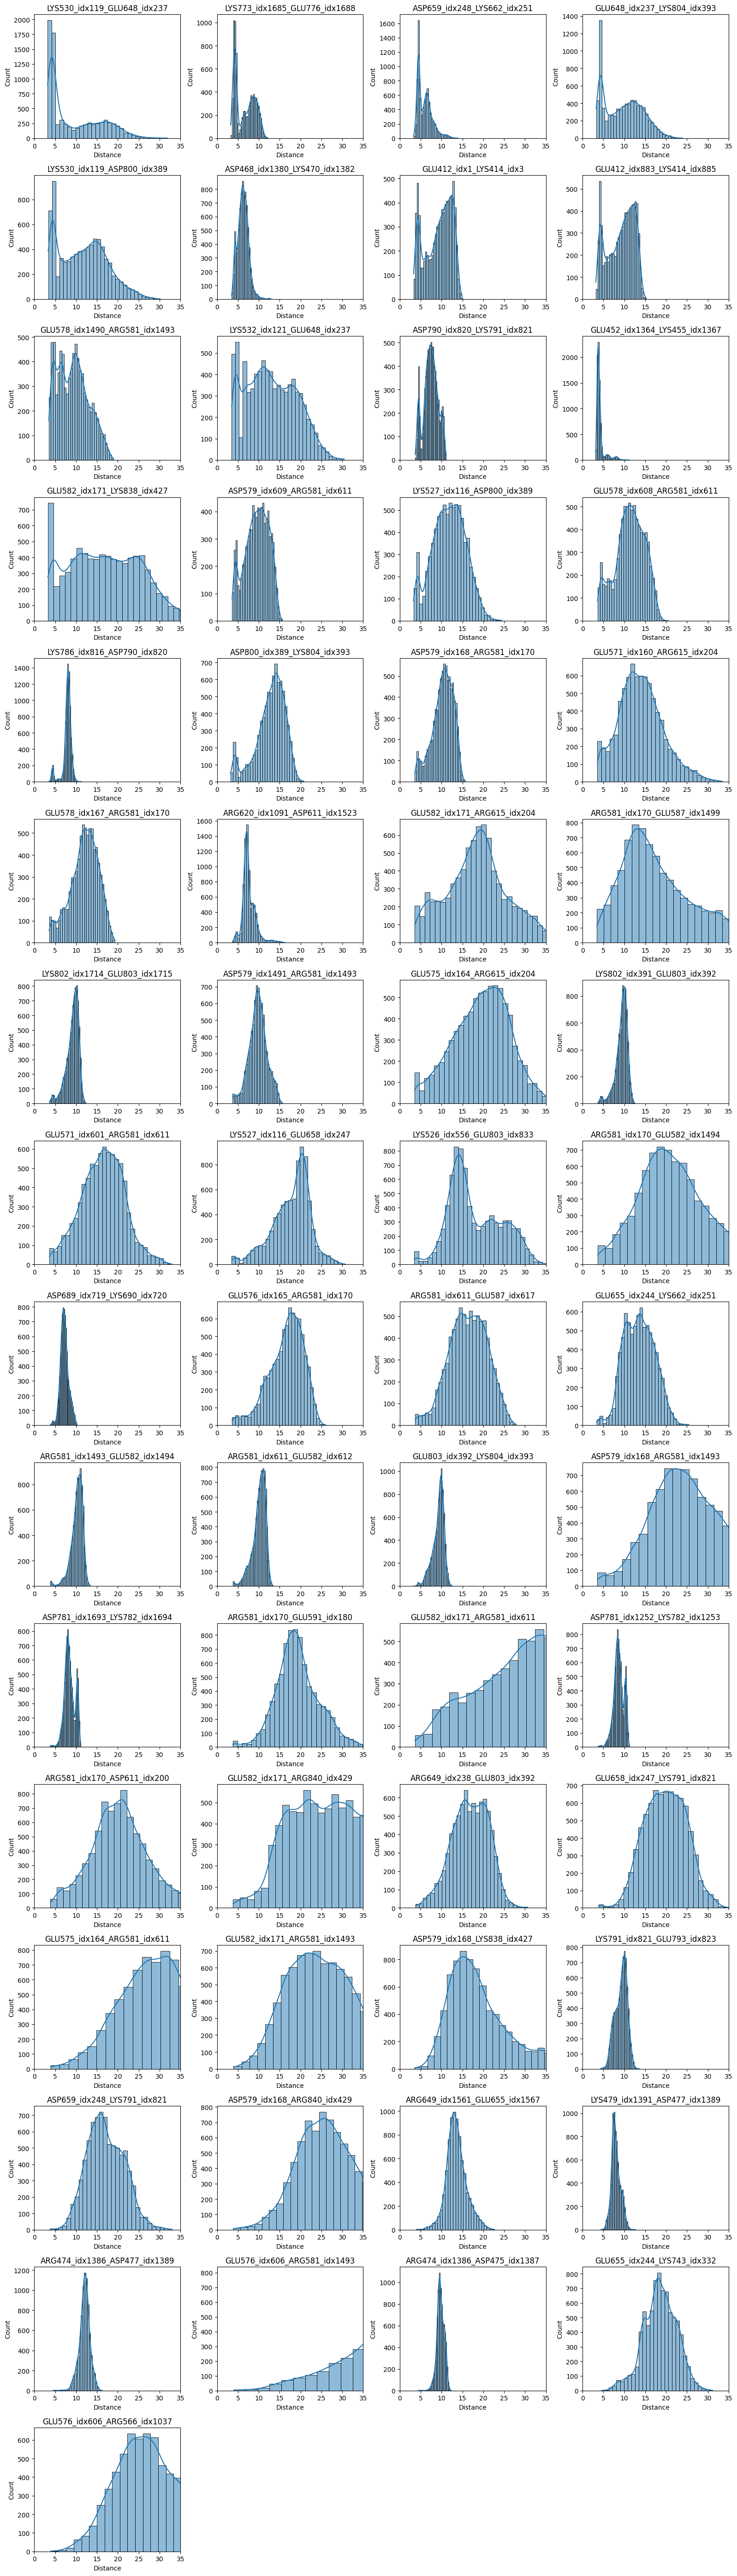

In [69]:
plot_salt_bridge_distributions(dist_df)

In [9]:
summary = dist_df.describe().T

summary = summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

print(summary)

                                count       mean        std       min  \
Salt bridge                                                             
LYS530_idx119_GLU648_idx237    8016.0   9.385532   6.268900  3.166749   
LYS773_idx1685_GLU776_idx1688  8016.0   6.677593   2.316024  3.254385   
ASP659_idx248_LYS662_idx251    8016.0   6.009688   1.734781  3.270500   
GLU648_idx237_LYS804_idx393    8016.0   9.769840   4.466235  3.254917   
LYS530_idx119_ASP800_idx389    8016.0  11.686127   5.672617  3.332042   
...                               ...        ...        ...       ...   
ARG474_idx1386_ASP477_idx1389  8016.0  12.030512   1.260073  4.511360   
GLU576_idx606_ARG581_idx1493   8016.0  49.150286  13.286865  4.025677   
ARG474_idx1386_ASP475_idx1387  8016.0   9.760245   0.870442  4.434684   
GLU655_idx244_LYS743_idx332    8016.0  18.559316   3.921720  4.553686   
GLU576_idx606_ARG566_idx1037   8016.0  30.157852   9.944764  3.945466   

                                     25%        50

## PLS ##

In [10]:
# Here add the function data to be used in PLS
data = np.load(DATA / "AMPAR.npz")
function_values = data["fval"]
function_values = function_values[::10] # every tenth frame
Y = function_values
print(Y.shape)

(8016,)


In [11]:
distance_scaled = shap_functions.scale_features(distance_map)
print(distance_scaled.shape)
X_scaled = ba.create_contact_dataframe(contact_map_names, distance_scaled)

(8016, 61)


Done! Built models up to 10 components.


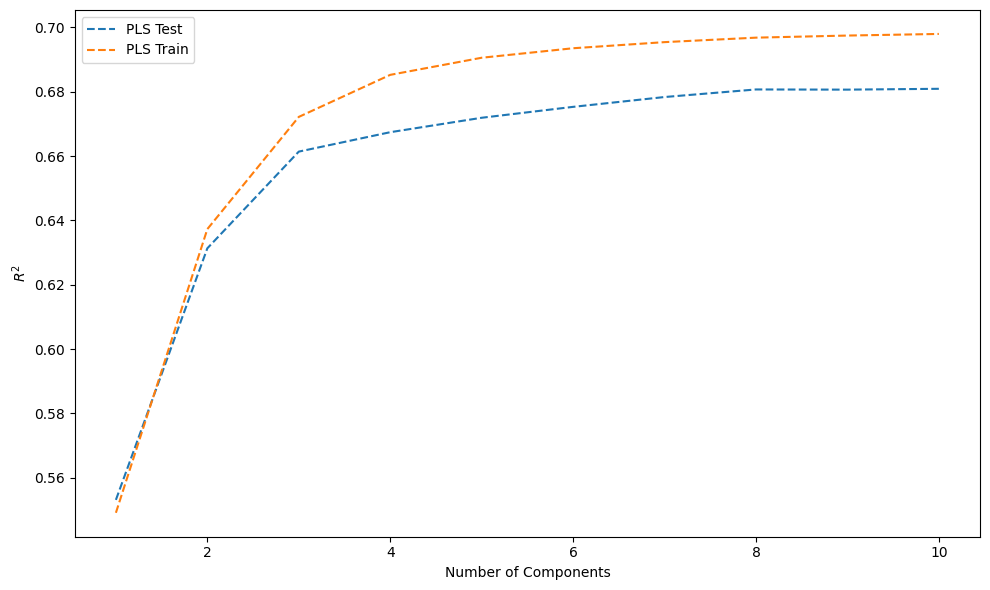

In [12]:
scores = shap_functions.optimize_n_components(X_scaled, Y, maxcomp=10)

In [15]:
pls = shap_functions.pls_model(X_scaled, Y, 8)

## SHAP ##

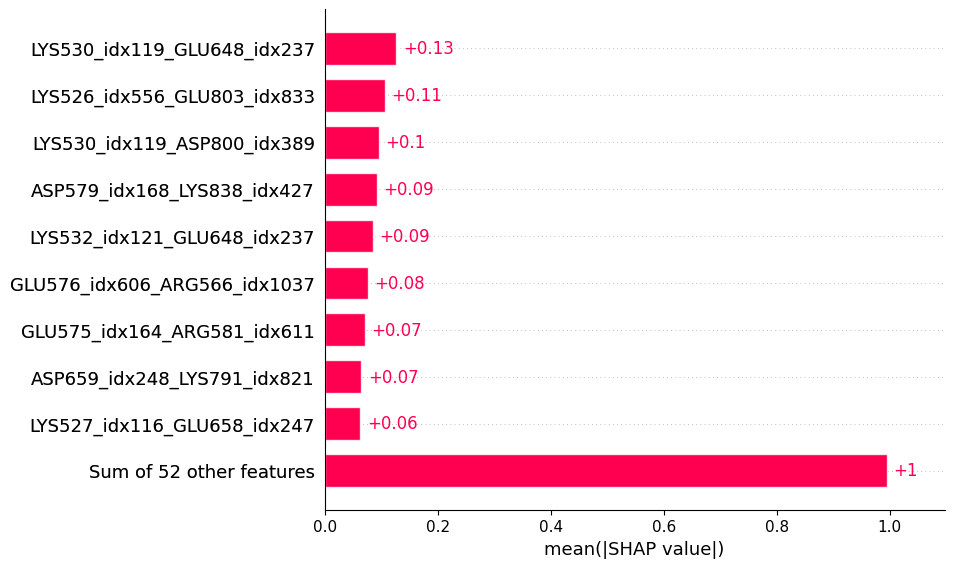

In [19]:
shap_values_pls = shap_functions.compute_shap_values(pls, X_scaled)
shap.plots.bar(shap_values_pls)
feature_names = shap_values_pls.feature_names

## PCA ##

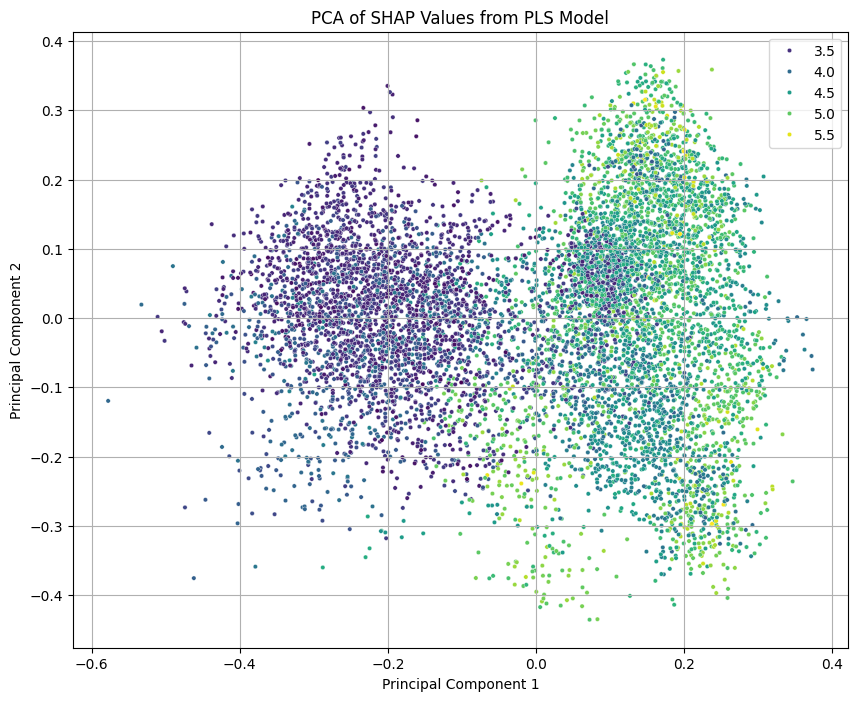

In [71]:
n_components = 8

# Fit PCA on the scaled SHAP values
pca = PCA(n_components=n_components)  
pca_result = pca.fit_transform(shap_values_array)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=[f'Principal Component {i+1}' for i in range(n_components)])

# Plotting only the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=pca_df, hue=Y, palette='viridis', s=10)
plt.title('PCA of SHAP Values from PLS Model')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

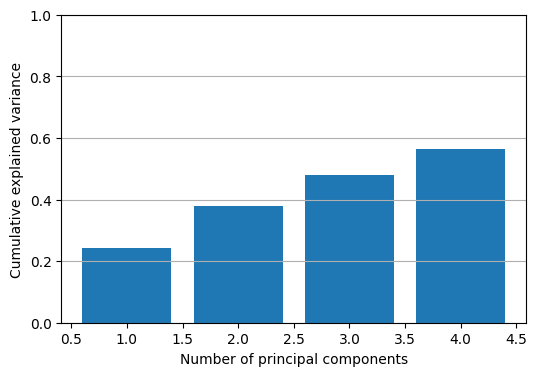

In [56]:

shap_pca,pca = shap_functions.dimensionality_reduction_pca(shap_values_pls, n_comp=4)

In [93]:
def check_clusters(cluster_labels):
    """
    Check which clusters are populated and how many observations
    belong to each cluster.
    """
    unique_clusters, cluster_counts = np.unique(
        cluster_labels,
        return_counts=True
    )

    print("Clusters found:")
    
    for cluster, count in zip(unique_clusters, cluster_counts):
        print(f"Cluster {cluster}: {count} observations")

    print(f"\nNumber of populated clusters: {len(unique_clusters)}")

    return unique_clusters, cluster_counts

def cluster_shap_values(shap_pca, shap_values, Y, n_components=4, reg_covar=0.001):
    
    if isinstance(shap_values, shap.Explanation):
        feature_names = shap_values.feature_names
        shap_values = shap_values.values
    else:
        shap_values = np.asarray(shap_values)
        feature_names = [f"Feature_{i}" for i in range(shap_values.shape[1])]

    shap_pca = np.asarray(shap_pca)

    gmm = BGMM(
        n_components=n_components,
        reg_covar=reg_covar,
        max_iter=1000,
        tol=1e-4,
        random_state=42
    )

    cluster_labels = gmm.fit_predict(shap_pca)
    shap_df = pd.DataFrame(shap_values, columns=feature_names)
    shap_df['Cluster'] = cluster_labels
    shap_df['Function Value'] = Y  # Add the function Y values

    return gmm, cluster_labels, shap_df, feature_names


In [105]:
gmm, cluster_labels, shap_df, feature_names = cluster_shap_values(
    shap_pca,
    shap_values_pls,
    Y,
    n_components=2,
    reg_covar=0.001
)



In [106]:
unique_clusters, cluster_counts = check_clusters(
    cluster_labels
)

Clusters found:
Cluster 0: 4831 observations
Cluster 1: 3185 observations

Number of populated clusters: 2


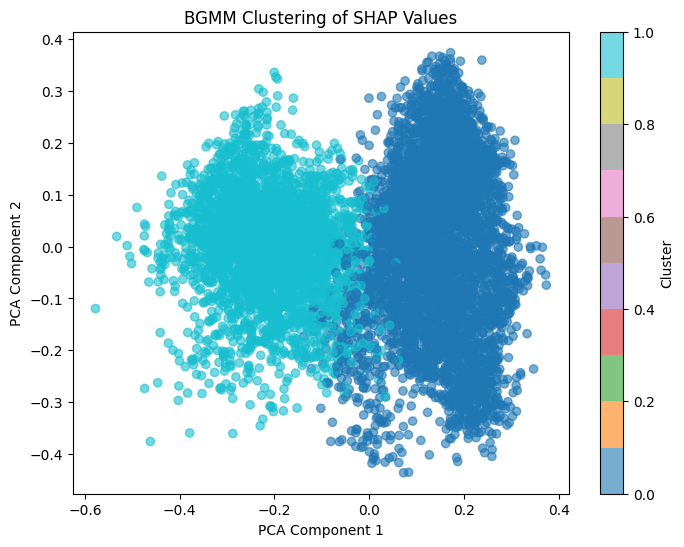

In [107]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    shap_pca[:, 0],
    shap_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.6
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("BGMM Clustering of SHAP Values")
plt.show()


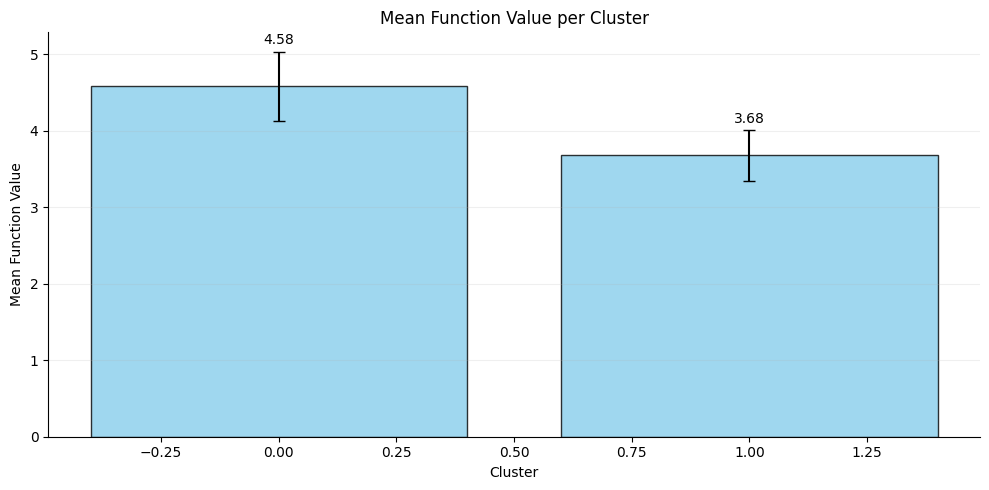

In [108]:
stats = shap_df.groupby("Cluster")["Function Value"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
)

ax.bar_label(bars, fmt="%.2f", padding=3)

ax.set(
    xlabel="Cluster",
    ylabel="Mean Function Value",
    title="Mean Function Value per Cluster",
)

ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


(array([ 556., 1543.,  767.,  832.,  958.,  855.,  931., 1089.,  440.,
          45.]),
 array([3.15747629, 3.40199341, 3.64651052, 3.89102764, 4.13554475,
        4.38006187, 4.62457898, 4.8690961 , 5.11361321, 5.35813033,
        5.60264744]),
 <BarContainer object of 10 artists>)

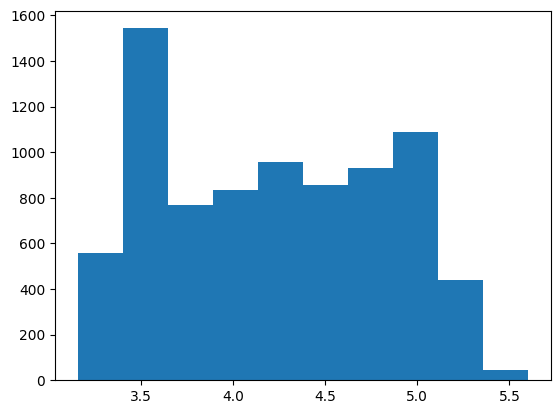

In [109]:
plt.hist(Y)

In [116]:
print(shap_df)

      ASP781_idx1693_LYS782_idx1694  LYS802_idx1714_GLU803_idx1715  \
0                          0.012649                       0.060538   
1                          0.012006                       0.051588   
2                         -0.001711                       0.185126   
3                          0.003199                       0.057921   
4                          0.001374                      -0.016943   
...                             ...                            ...   
8011                       0.012753                       0.021670   
8012                       0.013452                      -0.056600   
8013                       0.013131                      -0.062045   
8014                       0.012109                      -0.079816   
8015                       0.012998                      -0.097459   

      LYS773_idx1685_GLU776_idx1688  ARG581_idx170_GLU587_idx1499  \
0                         -0.011790                     -0.020523   
1                    

In [125]:
df_ones = shap_df[shap_df["Cluster"] == 1].copy()
df_zeros = shap_df[shap_df["Cluster"] == 0].copy()
df_ones = df_ones.drop(columns=["Function Value"])
df_zeros = df_zeros.drop(columns=["Function Value"])

means_ones = df_ones.drop(columns="Cluster").mean()
means_zeros = df_zeros.drop(columns="Cluster").mean()

max_ones, min_ones = means_ones.idxmax(), means_ones.idxmin() 
max_zeros, min_zeros = means_zeros.idxmax(), means_zeros.idxmin()

print("Cluster 1:") 
print(" MAX:", max_ones, means_ones[max_ones], "| Cluster 0 mean:", df_zeros[max_ones].mean()) 
print(" MIN:", min_ones, means_ones[min_ones], "| Cluster 0 mean:", df_zeros[min_ones].mean()) 
print("\nCluster 0:") 
print(" MAX:", max_zeros, means_zeros[max_zeros], "| Cluster 1 mean:", df_ones[max_zeros].mean()) 
print(" MIN:", min_zeros, means_zeros[min_zeros], "| Cluster 1 mean:", df_ones[min_zeros].mean())

Cluster 1:
 MAX: ASP579_idx168_LYS838_idx427 0.012188046216217578 | Cluster 0 mean: -0.01989346443024296
 MIN: LYS530_idx119_GLU648_idx237 -0.16057704272742757 | Cluster 0 mean: 0.10271242087758413

Cluster 0:
 MAX: LYS530_idx119_GLU648_idx237 0.10271242087758413 | Cluster 1 mean: -0.16057704272742757
 MIN: ASP579_idx168_LYS838_idx427 -0.01989346443024296 | Cluster 1 mean: 0.012188046216217578


In [123]:
means_cluster_one = df_ones.drop(columns="Cluster").mean().sort_values(ascending=False)
means_cluster_zero = df_zeros.drop(columns="Cluster").mean().sort_values(ascending=False)
print(means_cluster_one)

ASP579_idx168_LYS838_idx427      0.012188
GLU578_idx1490_ARG581_idx1493    0.010462
GLU576_idx606_ARG581_idx1493     0.007537
LYS530_idx119_ASP800_idx389      0.005867
GLU582_idx171_ARG581_idx611      0.005464
                                   ...   
GLU648_idx237_LYS804_idx393     -0.033000
LYS526_idx556_GLU803_idx833     -0.035711
GLU576_idx606_ARG566_idx1037    -0.045624
LYS532_idx121_GLU648_idx237     -0.094520
LYS530_idx119_GLU648_idx237     -0.160577
Length: 61, dtype: float64


In [121]:
print(means_cluster_zero)

LYS530_idx119_GLU648_idx237     0.102712
LYS532_idx121_GLU648_idx237     0.068514
LYS526_idx556_GLU803_idx833     0.048181
GLU576_idx606_ARG566_idx1037    0.047618
GLU575_idx164_ARG581_idx611     0.030340
                                  ...   
GLU576_idx606_ARG581_idx1493   -0.007580
GLU571_idx601_ARG581_idx611    -0.008408
LYS530_idx119_ASP800_idx389    -0.009945
LYS527_idx116_GLU658_idx247    -0.011082
ASP579_idx168_LYS838_idx427    -0.019893
Length: 61, dtype: float64
